# Goal
The goal is to use a simple model to classify x-ray images in Keras, the notebook how to use the ```flow_from_dataframe``` to deal with messier datasets

In [1]:
# !pip install timm transformers datasets accelerate opencv-python scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt

import cv2
import math
from PIL import Image
from tqdm import tqdm
import sys

import timm
from sklearn.metrics import roc_auc_score
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:

IS_BATCH = os.environ.get("KAGGLE_KERNEL_RUN_TYPE", "Interactive") != "Interactive"


#@ Trả kwargs chuẩn cho tqdm, tự đổi hành vi theo Interactive vs Batch của Kaggle
def pbar_kwargs(desc, **extra):
    return dict(
        desc=desc,
        leave=False,
        file=sys.stdout,        #? mặc định tqdm ghi stderr → Kaggle bôi đỏ hết log; đẩy sang stdout cho sạch
        ascii=True,             #? tránh ký tự block unicode bị mojibake trong log file
        ncols=80,
        dynamic_ncols=False,    #? batch không có terminal width, để True sẽ query TTY và nhảy lung tung
        mininterval=30.0 if IS_BATCH else 0.5,  #! đây là dòng quan trọng nhất — batch mode 1 dòng/30s thay vì 10 dòng/giây
        **extra,
    )

In [4]:
all_xray_df = pd.read_csv('/kaggle/input/data/Data_Entry_2017.csv')

all_image_paths = {
    os.path.basename(x): x
    for x in glob('/kaggle/input/data/images*/*/*.png')  #? path tuyệt đối, khớp gốc với dòng CSV ở trên
}

print('Scans found:', len(all_image_paths), ', Total Headers', all_xray_df.shape[0])
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

Scans found: 112120 , Total Headers 112120


In [5]:
all_xray_df["Patient Age"] = all_xray_df["Patient Age"].astype(np.int16)  #! astype trả bản copy, không gán lại thì cột vẫn nguyên dtype cũ
all_xray_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,/kaggle/input/data/images_001/images/00000001_...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,/kaggle/input/data/images_001/images/00000001_...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,/kaggle/input/data/images_001/images/00000001_...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,/kaggle/input/data/images_001/images/00000002_...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,/kaggle/input/data/images_001/images/00000003_...


# Preprocessing Labels
Here we take the labels and make them into a more clear format. The primary step is to see the distribution of findings and then to convert them to simple binary labels

In [6]:
label_counts = all_xray_df['Finding Labels'].value_counts()[:15]
# fig, ax1 = plt.subplots(1,1,figsize = (12, 8))
# ax1.bar(np.arange(len(label_counts))+0.5, label_counts)
# ax1.set_xticks(np.arange(len(label_counts))+0.5)
# _ = ax1.set_xticklabels(label_counts.index, rotation = 90)
label_counts

Finding Labels
No Finding                  60361
Infiltration                 9547
Atelectasis                  4215
Effusion                     3955
Nodule                       2705
Pneumothorax                 2194
Mass                         2139
Effusion|Infiltration        1603
Atelectasis|Infiltration     1350
Consolidation                1310
Atelectasis|Effusion         1165
Pleural_Thickening           1126
Cardiomegaly                 1093
Emphysema                     892
Infiltration|Nodule           829
Name: count, dtype: int64

In [7]:
from itertools import chain

all_xray_df["Finding Labels"] = all_xray_df["Finding Labels"].map(lambda x: x.replace("No Finding", ""))

label_sets = all_xray_df["Finding Labels"].map(lambda f: {t for t in f.split("|") if t})  #? tách token 1 lần rồi tái dùng, thay vì split lại 14 lượt trong vòng for

all_labels = sorted(set(chain.from_iterable(label_sets)))
print("All Labels ({}): {}".format(len(all_labels), all_labels))

for c_label in all_labels:
    #! exact token match, KHÔNG dùng `c_label in finding` — substring match hiện đúng với NIH-14 chỉ vì tình cờ không nhãn nào là substring của nhãn khác
    all_xray_df[c_label] = label_sets.map(lambda s, c=c_label: 1.0 if c in s else 0.0).astype(np.float32)

all_xray_df["path"].sample(3)

All Labels (14): ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


20536    /kaggle/input/data/images_003/images/00005499_...
61334    /kaggle/input/data/images_007/images/00015136_...
9154     /kaggle/input/data/images_002/images/00002395_...
Name: path, dtype: object

In [8]:
all_xray_df.iloc[37495], all_labels

(Image Index                                                     00009889_007.png
 Finding Labels                                             Atelectasis|Pneumonia
 Follow-up #                                                                    7
 Patient ID                                                                  9889
 Patient Age                                                                   24
 Patient Gender                                                                 M
 View Position                                                                 PA
 OriginalImage[Width                                                         2048
 Height]                                                                     2500
 OriginalImagePixelSpacing[x                                                0.168
 y]                                                                         0.168
 Unnamed: 11                                                                  NaN
 path           

### Clean categories
Since we have too many categories, we can prune a few out by taking the ones with only a few examples

In [9]:
# keep at least 1000 cases
MIN_CASES = 1000
all_labels = [c_label for c_label in all_labels if all_xray_df[c_label].sum()>MIN_CASES]
print('Clean Labels ({})'.format(len(all_labels)), 
      [(c_label,int(all_xray_df[c_label].sum())) for c_label in all_labels])

Clean Labels (13) [('Atelectasis', 11559), ('Cardiomegaly', 2776), ('Consolidation', 4667), ('Edema', 2303), ('Effusion', 13317), ('Emphysema', 2516), ('Fibrosis', 1686), ('Infiltration', 19894), ('Mass', 5782), ('Nodule', 6331), ('Pleural_Thickening', 3385), ('Pneumonia', 1431), ('Pneumothorax', 5302)]


# Prepare Training Data
Here we split the data into training and validation sets and create a single vector (disease_vec) with the 0/1 outputs for the disease status (what the model will try and predict)

In [10]:
disease_mat = all_xray_df[all_labels].to_numpy(np.float32)  #? (N, 13) — thay cho apply(axis=1) trả object array, nhanh hơn ~100x

all_xray_df["n_findings"] = disease_mat.sum(1)  #? sample weight chỉ cần tổng, không cần giữ cả vector
all_xray_df["disease_vec"] = list(disease_mat)  #? vẫn giữ cột cho phần CAM demo cuối notebook, nhưng giờ mỗi phần tử là np.float32 array thật

print(all_xray_df["n_findings"].value_counts().sort_index())

n_findings
0.0    60471
1.0    30926
2.0    14268
3.0     4826
4.0     1245
5.0      299
6.0       66
7.0       16
8.0        1
9.0        2
Name: count, dtype: int64


In [11]:
def read_txt_list(txt_path):
    with open(txt_path, "r") as f:
        items = [line.strip() for line in f.readlines()]

    items = [x for x in items if x != ""]
    return items

train_val_list_path = "/kaggle/input/data/train_val_list.txt"
test_list_path = "/kaggle/input/data/test_list.txt"

train_val_list = read_txt_list(train_val_list_path)
test_list = read_txt_list(test_list_path)

print("train_val:", len(train_val_list))
print("test:", len(test_list))

train_val_set = set(train_val_list)
test_set = set(test_list)

train_val_df = all_xray_df[all_xray_df["Image Index"].isin(train_val_set)].reset_index(drop=True)
test_df = all_xray_df[all_xray_df["Image Index"].isin(test_set)].reset_index(drop=True)

print("train_val_df:", train_val_df.shape)
print("test_df:", test_df.shape)

train_val: 86524
test: 25596
train_val_df: (86524, 29)
test_df: (25596, 29)


Check xem có ảnh nào trong txt nhưng không có trong df không:

In [12]:
df_image_set = set(all_xray_df["Image Index"].astype(str).values)

missing_train_val = train_val_set - df_image_set
missing_test = test_set - df_image_set

print("missing train_val:", len(missing_train_val))
print("missing test:", len(missing_test))

print("sample missing train_val:", list(missing_train_val)[:5])
print("sample missing test:", list(missing_test)[:5])

missing train_val: 0
missing test: 0
sample missing train_val: []
sample missing test: []


In [13]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=1604)

#! group theo Patient ID — NIH ~30k bệnh nhân / 112k ảnh, chia theo ảnh khiến cùng 1 người nằm cả train lẫn val và thổi phồng val AUC ~1.6 điểm
tr_idx, va_idx = next(gss.split(train_val_df, groups=train_val_df["Patient ID"]))

train_df = train_val_df.iloc[tr_idx].reset_index(drop=True)
valid_df = train_val_df.iloc[va_idx].reset_index(drop=True)

print("train", len(train_df), "| valid", len(valid_df))
print("patient overlap:", len(set(train_df["Patient ID"]) & set(valid_df["Patient ID"])))  #? phải ra 0
print("prevalence gap tối đa:", (train_df[all_labels].mean() - valid_df[all_labels].mean()).abs().max())
#? GroupShuffleSplit không stratify được — check gap này, dưới ~0.01 là chấp nhận, cao hơn thì đổi random_state

train 60444 | valid 26080
patient overlap: 0
prevalence gap tối đa: 0.005150645971298218


# Cache Dataset
chỉ chạy nếu chưa cache / preprocess trước

In [14]:

# import shutil

# CACHE_S = 256


# #@ Chọn thư mục cache có đủ chỗ trống, ưu tiên nơi không bị tính vào output quota
# #@ Raise nếu không chỗ nào đủ — tốt hơn là để memmap ghi nửa chừng rồi hết disk
# def pick_cache_dir(need_bytes):
#     for d in ["/kaggle/working","/kaggle/temp", "/tmp"]:  #? /kaggle/working là cuối cùng — nó bị commit làm output và giới hạn 20GB
#         os.makedirs(d, exist_ok=True)  #! đây là dòng thiếu — mode="w+" tạo file chứ không tạo parent dir

#         free = shutil.disk_usage(d).free
#         if free > need_bytes * 1.15:  #? chừa 15% headroom, đừng ghi sát trần disk
#             print(f"cache dir: {d} (free {free / 1e9:.1f}GB)")
#             return d

#     raise RuntimeError(f"không thư mục nào đủ {need_bytes / 1e9:.1f}GB")


# cache_df = all_xray_df.dropna(subset=["path"]).reset_index(drop=True)
# N_TOTAL = len(cache_df)

# CACHE_DIR = pick_cache_dir(N_TOTAL * CACHE_S * CACHE_S)

# CACHE_PATH = os.path.join(CACHE_DIR, f"xray_{CACHE_S}.u8")
# META_PATH = os.path.join(CACHE_DIR, f"xray_{CACHE_S}_index.npy")

In [15]:
# from multiprocessing import Pool
 
# cv2.setNumThreads(0)  #! bắt buộc — cv2 mặc định tự spawn thread, sẽ oversubscribe khi chạy trong Pool/DataLoader worker
 
 
# #@ Worker: decode + resize 1 chunk paths, ghi vào memmap tại offset tương ứng
# #@ Trả về (số ảnh ghi thành công, list path lỗi) để caller kiểm tra tính toàn vẹn
# def _fill_chunk(args):
#     start, paths, n_total = args

#     mm = np.memmap(CACHE_PATH, dtype=np.uint8, mode="r+", shape=(n_total, CACHE_S, CACHE_S))
#     ok, bad = 0, []

#     for k, p in enumerate(paths):
#         img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)

#         if img is None:  #! imread không raise khi file hỏng/sai path — phải tự check
#             bad.append(p)
#             continue

#         mm[start + k] = cv2.resize(img, (CACHE_S, CACHE_S), interpolation=cv2.INTER_AREA)
#         ok += 1

#     mm.flush()
#     del mm
#     return ok, bad
 
 
# #@ Build cache uint8 grayscale từ list path ảnh gốc, chạy song song trên toàn bộ core
# #@ Trả về dict {image_name -> row index trong memmap} để dataset tra cứu sau này
# #@ Idempotent: đã có cache thì load meta và return luôn
# def build_cache(paths, names, n_proc=4):
#     n = len(paths)
 
#     if os.path.exists(CACHE_PATH) and os.path.exists(META_PATH):
#         print("cache đã tồn tại, skip")
#         return {k: i for i, k in enumerate(np.load(META_PATH, allow_pickle=True))}
 
#     mm = np.memmap(CACHE_PATH, dtype=np.uint8, mode="w+", shape=(n, CACHE_S, CACHE_S))
#     del mm  #? tạo file rỗng đúng size trước, các worker sau đó mở mode="r+" ghi song song vào cùng file
 
#     chunk = 512
#     jobs = [(i, paths[i:i + chunk], n) for i in range(0, n, chunk)]
 
#     with Pool(n_proc) as pool:
#         done, all_bad = 0, []
#         for ok, bad in pool.imap_unordered(_fill_chunk, jobs):
#             done += ok
#             all_bad.extend(bad)
#             if done % 10240 < chunk:
#                 print(f"  {done}/{n}")

#     #! chỉ save meta khi mọi ảnh đều ghi được — sự tồn tại của META_PATH chính là cờ "cache hợp lệ" cho lần chạy sau
#     if all_bad:
#         raise RuntimeError(f"{len(all_bad)} ảnh lỗi, vd: {all_bad[:3]}")

#     np.save(META_PATH, np.array(names, dtype=object))
#     return {k: i for i, k in enumerate(names)}
 
 
# # ── chạy build ──
# cache_df = all_xray_df.dropna(subset=["path"]).reset_index(drop=True)
# name2row = build_cache(
#     paths=cache_df["path"].tolist(),
#     names=cache_df["Image Index"].tolist(),
#     n_proc=4,
# )

In [16]:
# print(len(all_image_paths))          # nếu ra 0 → glob không match được gì
# print(all_xray_df['path'].notna().sum())   # số ảnh map được

# Load Preprocessed Data

In [17]:
CACHE_S = 256
CACHE_DIR = "/kaggle/input/datasets/longphmchu/processed-x-ray"

CACHE_PATH = os.path.join(CACHE_DIR, "xray_256.u8")
META_PATH = os.path.join(CACHE_DIR, "xray_256_index.npy")

In [18]:
names = np.load(META_PATH, allow_pickle=True)

name2row = {
    name: i
    for i, name in enumerate(names)
}

# Create Data Generators
Here we make the data generators for loading and randomly transforming images

In [19]:
CFG = {
    "label_cols": list(all_labels),

    "backbone": "densenet121",      # thử: densenet121, convnext_tiny, efficientnet_b0
    "pretrained": True,
    "image_size": 224,
    "transition_dim": 1024,
    "pooling": "lse",            # "avg", "max", "lse"
    "lse_r": 10.0,

    "epochs": 20,
    "batch_size": 128,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "num_workers": 3,
}
# ============================================================
# LR schedule + Early stopping config
# ============================================================

CFG["warmup_epochs"] = 1
CFG["warmup_start_factor"] = 0.1   # bắt đầu từ 10% base LR
CFG["min_lr"] = 1e-6

CFG["early_stopping_patience"] = 5
CFG["early_stopping_min_delta"] = 1e-4

In [20]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

OUT_S = 224
 
 
class XrayCachedDataset(Dataset):
    #@ Dataset đọc trực tiếp từ memmap uint8 đã pre-resize — không decode, không PIL, không pandas
    #@ Trả về tensor uint8 (1,224,224); việc float/normalize đẩy sang GPU để tiết kiệm CPU
    def __init__(self, df, name2row, label_cols, n_total, train=False):
        self.rows = np.array([name2row[n] for n in df["Image Index"]], dtype=np.int64)  #? resolve index 1 lần ở __init__, __getitem__ chỉ còn lookup mảng int
        self.labels = df[label_cols].to_numpy(dtype=np.float32)  #! convert sang numpy ngay — .iloc[idx] trên DataFrame mixed-dtype tốn ~1ms/sample dưới GIL
        self.labels = np.nan_to_num(self.labels, nan=0.0)
 
        self.n_total = n_total
        self.train = train
        self.mm = None  #! memmap phải mở lazy trong worker, mở ở __init__ sẽ bị pickle/fork sai handle
 
    def __len__(self):
        return len(self.rows)
 
    def __getitem__(self, idx):
        if self.mm is None:
            self.mm = np.memmap(CACHE_PATH, dtype=np.uint8, mode="r", shape=(self.n_total, CACHE_S, CACHE_S))
 
        img = self.mm[self.rows[idx]]
 
        if self.train:
            y = np.random.randint(0, CACHE_S - OUT_S + 1)
            x = np.random.randint(0, CACHE_S - OUT_S + 1)
            img = img[y:y + OUT_S, x:x + OUT_S]
 
            if np.random.rand() < 0.5:
                img = img[:, ::-1]  #? horizontal flip bằng negative stride — không copy, copy() phía dưới lo phần contiguous
        else:
            o = (CACHE_S - OUT_S) // 2
            img = img[o:o + OUT_S, o:o + OUT_S]  #? center crop cho val để deterministic
 
        return {
            "pixel_values": torch.from_numpy(np.ascontiguousarray(img)).unsqueeze(0),  #? giữ uint8: transfer PCIe nhẹ hơn float32 4 lần
            "labels": torch.from_numpy(self.labels[idx]),
        }
 

In [21]:
cache_df = all_xray_df.dropna(subset=["path"]).reset_index(drop=True)
N_TOTAL = len(cache_df)

train_ds = XrayCachedDataset(train_df, name2row, CFG["label_cols"], N_TOTAL, train=True)
val_ds = XrayCachedDataset(valid_df, name2row, CFG["label_cols"], N_TOTAL, train=False)
test_ds = XrayCachedDataset(test_df, name2row, CFG["label_cols"], N_TOTAL, train=False)

In [22]:


# Datasets and Dataloader
train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    persistent_workers=True,   # thêm dòng này
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    persistent_workers=True,
)
len(train_ds), len(val_ds)

(60444, 26080)

# Model

In [23]:
class GlobalPool2d(nn.Module):
    def __init__(self, mode="lse", lse_r=10.0):
        super().__init__()
        assert mode in ["avg", "max", "lse"]
        self.mode = mode
        self.lse_r = lse_r

    def forward(self, x):
        if self.mode == "avg":
            return x.mean(dim=(-2, -1))

        if self.mode == "max":
            return x.amax(dim=(-2, -1))

        # Log-Sum-Exp pooling
        b, c, h, w = x.shape
        flat = x.flatten(2)
        m = flat.amax(dim=-1, keepdim=True)
        pooled = m + torch.log(torch.exp((flat - m) * self.lse_r).mean(dim=-1, keepdim=True)) / self.lse_r
        return pooled.view(b, c)

In [24]:
class ChestLocalizationModel(nn.Module):
    def __init__(
        self,
        num_classes,
        backbone_name="resnet50",
        pretrained=True,
        transition_dim=1024,
        pooling="lse",
        lse_r=10.0,
        dropout=0.0,
    ):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            features_only=True,
            out_indices=(-1,),
        )

        backbone_channels = self.backbone.feature_info.channels()[-1]

        # Transition layer: đưa activation từ pretrained model về dimension thống nhất
        self.transition = nn.Sequential(
            nn.Conv2d(backbone_channels, transition_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(transition_dim),
            nn.ReLU(inplace=True),
        )

        self.pool = GlobalPool2d(pooling, lse_r=lse_r)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # Prediction layer
        self.classifier = nn.Linear(transition_dim, num_classes)

    def forward(self, pixel_values, return_features=False):
        features = self.backbone(pixel_values)[-1]
        transition_features = self.transition(features)
        pooled_features = self.pool(transition_features)
        logits = self.classifier(self.dropout(pooled_features))

        if return_features:
            return {
                "logits": logits,
                "transition_features": transition_features,
                "pooled_features": pooled_features,
            }

        return logits

In [25]:
_mean = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
_std = torch.tensor(IMAGENET_STD, device=device).view(1, 3, 1, 1)


#@ Chuyển batch uint8 (B,1,H,W) từ loader sang float32 (B,3,H,W) đã normalize, toàn bộ trên GPU
def to_gpu_float(x):
    x = x.to(device, non_blocking=True).float().div_(255)
    x = x.expand(-1, 3, -1, -1)  #? expand không copy — 3 kênh cùng trỏ vào 1 vùng nhớ, conv1 đọc bình thường
    return (x - _mean) / _std  #! không dùng sub_/div_ in-place ở đây — x là expanded view, ghi in-place lên nó là undefined behavior

In [26]:
model = ChestLocalizationModel(
    num_classes=len(CFG["label_cols"]),
    backbone_name=CFG["backbone"],
    pretrained=CFG["pretrained"],
    transition_dim=CFG["transition_dim"],
    pooling=CFG["pooling"],
    lse_r=CFG["lse_r"],
).to(device)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
    print("train thành công trong nhiều GPU")

model = model.to(device)

pos = train_df[CFG["label_cols"]].sum().values
neg = len(train_df) - pos

ratio = np.sqrt(neg / pos)

pos_weight = torch.tensor(ratio, dtype=torch.float32, device=device)  #? per-class, cân positive trong loss thay vì méo phân bố ở sampler
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(dict(zip(CFG["label_cols"], ratio.round(2))))  #? in ra check trước khi train

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)
scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Using 2 GPUs
train thành công trong nhiều GPU
{'Atelectasis': np.float32(3.06), 'Cardiomegaly': np.float32(7.04), 'Consolidation': np.float32(5.47), 'Edema': np.float32(8.0), 'Effusion': np.float32(3.01), 'Emphysema': np.float32(7.62), 'Fibrosis': np.float32(8.15), 'Infiltration': np.float32(2.31), 'Mass': np.float32(4.5), 'Nodule': np.float32(4.18), 'Pleural_Thickening': np.float32(6.17), 'Pneumonia': np.float32(9.9), 'Pneumothorax': np.float32(5.63)}


In [27]:
# ============================================================
# Linear warmup -> Cosine decay
# Scheduler step theo từng optimizer step / batch
# ============================================================

steps_per_epoch = len(train_loader)

warmup_steps = CFG["warmup_epochs"] * steps_per_epoch
total_steps = CFG["epochs"] * steps_per_epoch

cosine_steps = max(
    1,
    total_steps - warmup_steps
)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=CFG["warmup_start_factor"],
    end_factor=1.0,
    total_iters=warmup_steps,
)

cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cosine_steps,
    eta_min=CFG["min_lr"],
)

scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[
        warmup_scheduler,
        cosine_scheduler,
    ],
    milestones=[warmup_steps],
)

print(f"steps/epoch   : {steps_per_epoch}")
print(f"warmup steps  : {warmup_steps}")
print(f"cosine steps  : {cosine_steps}")
print(f"initial LR    : {optimizer.param_groups[0]['lr']:.2e}")

steps/epoch   : 473
warmup steps  : 473
cosine steps  : 8987
initial LR    : 1.00e-05


In [28]:
#@ Tính AUC từng lớp + mean, bỏ qua lớp không có đủ cả nhãn 0 lẫn 1 trong tập eval
#@ Trả về (mean_auc: float, per_class: dict) — bản cũ chỉ trả dict, làm hỏng `val_auc > best_auc` và f-string trong training loop
def auc_per_class(y_true, y_prob, verbose=True):
    out = {}

    for i, name in enumerate(CFG["label_cols"]):
        if len(np.unique(y_true[:, i])) < 2:
            continue  #? ROC không định nghĩa được khi chỉ có 1 class

        out[name] = roc_auc_score(y_true[:, i], y_prob[:, i])

    mean_auc = float(np.mean(list(out.values()))) if out else 0.0

    if verbose:
        for name, auc in sorted(out.items(), key=lambda t: t[1]):
            print(f"  {name:20s} {auc:.4f}")
        print(f"  {'── MEAN':20s} {mean_auc:.4f}")

    return mean_auc, out

## Training and Evaluate functions

In [29]:
#@ Train 1 epoch, trả về (avg_loss, mean_auc, per_class)
#@ Scheduler step theo từng optimizer step -> warmup/cosine smooth hơn theo batch

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    scheduler=None,
):
    model.train()

    total_loss, n_seen = 0.0, 0
    all_logits, all_labels = [], []
    
    pbar = tqdm(loader, **pbar_kwargs("Train"))

    use_amp = str(device).startswith("cuda")

    for batch in pbar:
        pixel_values = to_gpu_float(batch["pixel_values"])
        labels = batch["labels"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            "cuda",
            enabled=use_amp,
        ):
            logits = model(pixel_values)
            loss = criterion(logits, labels)

        # =============================================
        # Backward + optimizer
        # =============================================
        scaler.scale(loss).backward()

        scale_before = scaler.get_scale()

        scaler.step(optimizer)
        scaler.update()

        scale_after = scaler.get_scale()

        # =============================================
        # LR scheduler
        #
        # Nếu AMP overflow:
        # scaler sẽ skip optimizer.step()
        # => không nên advance LR scheduler
        # =============================================
        optimizer_was_run = scale_after >= scale_before

        if scheduler is not None and optimizer_was_run:
            scheduler.step()

        # =============================================
        # Metrics
        # =============================================
        bs = pixel_values.size(0)

        total_loss += loss.item() * bs
        n_seen += bs

        all_logits.append(
            logits.detach().float().cpu()
        )

        all_labels.append(
            labels.detach().cpu()
        )

        current_lr = optimizer.param_groups[0]["lr"]

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{current_lr:.2e}",
        )

    y_prob = (
        torch.cat(all_logits)
        .sigmoid()
        .numpy()
    )

    y_true = (
        torch.cat(all_labels)
        .numpy()
    )

    mean_auc, per_class = auc_per_class(
        y_true,
        y_prob,
        verbose=False,
    )

    return (
        total_loss / n_seen,
        mean_auc,
        per_class,
    )

In [30]:
#@ Eval 1 epoch
#@ trả về (avg_loss, mean_auc, per_class, y_true, y_prob)

@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device,
    verbose=True,
):
    model.eval()

    total_loss, n_seen = 0.0, 0
    all_logits, all_labels = [], []

    pbar = tqdm(loader, **pbar_kwargs("Valid"))

    use_amp = str(device).startswith("cuda")

    for batch in pbar:
        pixel_values = to_gpu_float(
            batch["pixel_values"]
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True,
        )

        with torch.amp.autocast(
            "cuda",
            enabled=use_amp,
        ):
            logits = model(pixel_values)
            loss = criterion(logits, labels)

        bs = pixel_values.size(0)

        total_loss += loss.item() * bs
        n_seen += bs

        all_logits.append(
            logits.float().cpu()
        )

        all_labels.append(
            labels.cpu()
        )

        pbar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    y_prob = (
        torch.cat(all_logits)
        .sigmoid()
        .numpy()
    )

    y_true = (
        torch.cat(all_labels)
        .numpy()
    )

    mean_auc, per_class = auc_per_class(
        y_true,
        y_prob,
        verbose=verbose,
    )

    return (
        total_loss / n_seen,
        mean_auc,
        per_class,
        y_true,
        y_prob,
    )

# Training loop

In [31]:
best_auc = -float("inf")
epochs_without_improvement = 0

history = []

patience = CFG["early_stopping_patience"]
min_delta = CFG["early_stopping_min_delta"]


for epoch in range(1, CFG["epochs"] + 1):

    print(
        f"\nEpoch {epoch}/{CFG['epochs']}"
    )

    # =============================================
    # LR ở đầu epoch
    # =============================================
    lr_start = optimizer.param_groups[0]["lr"]

    # =============================================
    # Train
    # =============================================
    train_loss, train_auc, train_pc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        scheduler=scheduler,
    )

    # =============================================
    # Validation
    # =============================================
    val_loss, val_auc, val_pc, _, _ = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    lr_end = optimizer.param_groups[0]["lr"]

    # =============================================
    # History
    # =============================================
    history.append({
        "epoch": epoch,

        "train_loss": train_loss,
        "train_auc": train_auc,

        "val_loss": val_loss,
        "val_auc": val_auc,

        "lr_start": lr_start,
        "lr_end": lr_end,
    })

    print(
        f"train_loss={train_loss:.4f} | "
        f"train_auc={train_auc:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"lr={lr_end:.2e}"
    )

    # =============================================
    # Check improvement
    # =============================================
    improved = (
        val_auc > best_auc + min_delta
    )

    if improved:
        best_auc = val_auc
        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    # =============================================
    # Save LAST checkpoint
    #
    # Save đủ state để resume training
    # =============================================
    torch.save({
        "epoch": epoch,

        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),

        "config": CFG,
        "history": history,

        "best_auc": best_auc,

        "epochs_without_improvement":
            epochs_without_improvement,

    }, "last_model.pt")

    # =============================================
    # Save BEST checkpoint
    # =============================================
    if improved:

        torch.save({
            "epoch": epoch,

            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "scaler": scaler.state_dict(),

            "config": CFG,
            "history": history,

            "best_auc": best_auc,

        }, "best_model.pt")

        print(
            f"✓ Saved best_model.pt | "
            f"val_auc={best_auc:.4f}"
        )

    else:

        print(
            f"No improvement in val_auc | "
            f"{epochs_without_improvement}/{patience}"
        )

    # =============================================
    # EARLY STOPPING
    # =============================================
    if epochs_without_improvement >= patience:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        print(
            f"Best val AUC = {best_auc:.4f}"
        )

        break


Epoch 1/20
  Infiltration         0.6389
  Nodule               0.6489
  Pneumonia            0.6627
  Pleural_Thickening   0.7003
  Mass                 0.7005
  Fibrosis             0.7056
  Atelectasis          0.7342
  Consolidation        0.7371
  Pneumothorax         0.7532
  Cardiomegaly         0.7728
  Emphysema            0.7848
  Effusion             0.8033
  Edema                0.8531
  ── MEAN              0.7304
train_loss=0.5160 | train_auc=0.6302 | val_loss=0.4530 | val_auc=0.7304 | lr=9.96e-05
✓ Saved best_model.pt | val_auc=0.7304

Epoch 2/20
  Infiltration         0.6738
  Pneumonia            0.6919
  Nodule               0.7033
  Pleural_Thickening   0.7483
  Fibrosis             0.7665
  Consolidation        0.7682
  Mass                 0.7743
  Atelectasis          0.7766
  Pneumothorax         0.7953
  Emphysema            0.8425
  Effusion             0.8533
  Cardiomegaly         0.8691
  Edema                0.8848
  ── MEAN              0.7806
train_loss=

# Load trained model

In [32]:
model = ChestLocalizationModel(
    num_classes=len(CFG["label_cols"]),
    backbone_name=CFG["backbone"],
    pretrained=CFG["pretrained"],
    transition_dim=CFG["transition_dim"],
    pooling=CFG["pooling"],
    lse_r=CFG["lse_r"],
).to(device)

# ckpt = torch.load(
#     "/kaggle/input/models/longphmchu/dcnn-backbone-resnet50/pytorch/default/1/best_model.pt",
#     map_location="cpu"
# )

ckpt = torch.load(
    "/kaggle/working/best_model.pt",
    map_location="cpu"
)

state_dict = ckpt["model"]

state_dict = {
    k.removeprefix("module."): v
    for k, v in state_dict.items()
}

model.load_state_dict(state_dict)

<All keys matched successfully>

# Evaluate

In [33]:
val_loss, val_auc, val_pc, val_true, val_prob = validate_one_epoch(model, val_loader, criterion, device)
print()
test_loss, test_auc, test_pc, test_true, test_prob = validate_one_epoch(model, test_loader, criterion, device)

print(f"\nval  loss={val_loss:.4f}  mean_auc={val_auc:.4f}")
print(f"test loss={test_loss:.4f}  mean_auc={test_auc:.4f}")

#! đừng so val_loss với test_loss: split test official của NIH có prevalence khác train_val nên BCE lệch sẵn, chỉ AUC mới so được
print("\nprevalence:")
print(pd.DataFrame({"valid": valid_df[CFG["label_cols"]].mean(),
                    "test": test_df[CFG["label_cols"]].mean()}).round(4))

  Pneumonia            0.6905
  Infiltration         0.6914
  Nodule               0.7388
  Fibrosis             0.7668
  Consolidation        0.7787
  Pleural_Thickening   0.7884
  Atelectasis          0.7984
  Mass                 0.8211
  Pneumothorax         0.8290
  Effusion             0.8784
  Cardiomegaly         0.8859
  Emphysema            0.8884
  Edema                0.9019
  ── MEAN              0.8044

  Infiltration         0.6749
  Pneumonia            0.6903
  Consolidation        0.7174
  Nodule               0.7361
  Atelectasis          0.7422
  Pleural_Thickening   0.7490
  Mass                 0.7850
  Fibrosis             0.8025
  Effusion             0.8054
  Edema                0.8290
  Pneumothorax         0.8442
  Cardiomegaly         0.8610
  Emphysema            0.8835
  ── MEAN              0.7785

val  loss=0.4089  mean_auc=0.8044
test loss=0.6230  mean_auc=0.7785

prevalence:
                     valid    test
Atelectasis         0.0939  0.1281
Cardiom

In [34]:
print(val_loss, test_loss)

0.40885819971927106 0.6229672324710533


In [35]:
# ═══════════════════════════════════════════════════════════
# CAM (Class Activation Map) — 1 ảnh raw từ folder, bypass cache
# ═══════════════════════════════════════════════════════════


#@ Trả về module gốc, bóc lớp bọc DataParallel nếu có
def unwrap(m):
    return m.module if isinstance(m, nn.DataParallel) else m  #! DataParallel không forward attribute — model.backbone sẽ AttributeError khi chạy nhiều GPU


#@ Đọc 1 ảnh raw từ disk và preprocess đúng y hệt nhánh val của pipeline (không đụng memmap cache)
#@ Trả về (x: tensor (1,3,224,224) đã normalize trên device, gray: uint8 (224,224) để overlay)
def load_raw_image(image_path, cache_s=CACHE_S, out_s=OUT_S):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    #! imread trả None khi path sai / file hỏng chứ không raise — phải tự check
    if img is None:
        raise FileNotFoundError(image_path)

    img = cv2.resize(img, (cache_s, cache_s), interpolation=cv2.INTER_AREA)  #? phải khớp build_cache: INTER_AREA về 256 rồi mới crop, KHÔNG resize thẳng 224 như build_transform() (hàm đó thuộc dataset cũ đã bỏ)

    o = (cache_s - out_s) // 2
    img = img[o:o + out_s, o:o + out_s]  #? center crop, giống hệt nhánh train=False của XrayCachedDataset

    x = torch.from_numpy(np.ascontiguousarray(img)).unsqueeze(0).unsqueeze(0)  #? (1,1,224,224) uint8 — dựng đúng shape mà to_gpu_float mong đợi
    x = to_gpu_float(x)  #? tái dùng hàm cũ: /255 → expand 3 kênh → normalize ImageNet

    return x, img


#@ Forward qua backbone → transition, rồi nhân activation với weight của prediction layer để ra CAM thô
#@ Trả về (logits (C,), cam (C,h,w)) — cam chưa normalize, chưa upsample
@torch.no_grad()
def compute_cam(model, x):
    net = unwrap(model)  #? mọi truy cập submodule bên dưới đều qua net, không qua model

    features = net.backbone(x)[-1]  #? (1, 2048, 7, 7) với resnet50 @224 — stride tổng 32
    transition_activation = net.transition(features)  #? (1, 1024, 7, 7) — đúng cái "Activations from Transition layer" trong hình

    logits = net.classifier(net.pool(transition_activation))[0]  #? (C,) — dropout bỏ qua được vì đang eval()

    W = net.classifier.weight  #? (num_classes, transition_dim) = "Weights from prediction layer"
    cam = torch.einsum("cd,dhw->chw", W, transition_activation[0])  #? tổ hợp tuyến tính 1024 feature map theo trọng số riêng của từng class
    #? bias của classifier bỏ qua: nó là hằng số cho cả map, chỉ dịch level chứ không đổi vị trí vùng nóng

    #! CAM chuẩn chỉ đúng tuyệt đối khi pooling là avg (logit = mean của cam). Với lse/max thì nó chỉ là xấp xỉ — vẫn dùng được để localize nhưng đừng đọc giá trị cam như đóng góp trực tiếp vào logit

    return logits, cam


#@ Upsample 1 kênh CAM về size ảnh, min-max normalize rồi blend jet colormap lên ảnh gray
def cam_to_overlay(cam_c, gray, alpha=0.5):
    h = F.interpolate(cam_c[None, None].float(), size=gray.shape, mode="bilinear", align_corners=False)
    h = h[0, 0].cpu().numpy()
    h = (h - h.min()) / (h.max() - h.min() + 1e-8)  #? normalize theo từng class: giá trị tuyệt đối của cam không so sánh được giữa các class

    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * h), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    base = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    return np.uint8(alpha * heat + (1 - alpha) * base)


#@ Vẽ ảnh gốc + heatmap của top-k class có prob cao nhất
#@ Trả về vector prob (C,) để check thêm nếu cần
def show_cam(image_path, topk=3, alpha=0.5):
    x, gray = load_raw_image(image_path)
    logits, cam = compute_cam(model, x)
    probs = logits.sigmoid()

    idx = probs.topk(topk).indices.tolist()

    fig, axes = plt.subplots(1, topk + 1, figsize=(4 * (topk + 1), 4.5))
    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title(os.path.basename(str(image_path)), fontsize=10)
    axes[0].axis("off")

    for ax, c in zip(axes[1:], idx):
        ax.imshow(cam_to_overlay(cam[c], gray, alpha=alpha))
        ax.set_title(f"{CFG['label_cols'][c]}  p={probs[c]:.3f}", fontsize=11)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return probs.cpu().numpy()


Finding Labels                                                 Mass
disease_vec       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...
Name: 1020, dtype: object


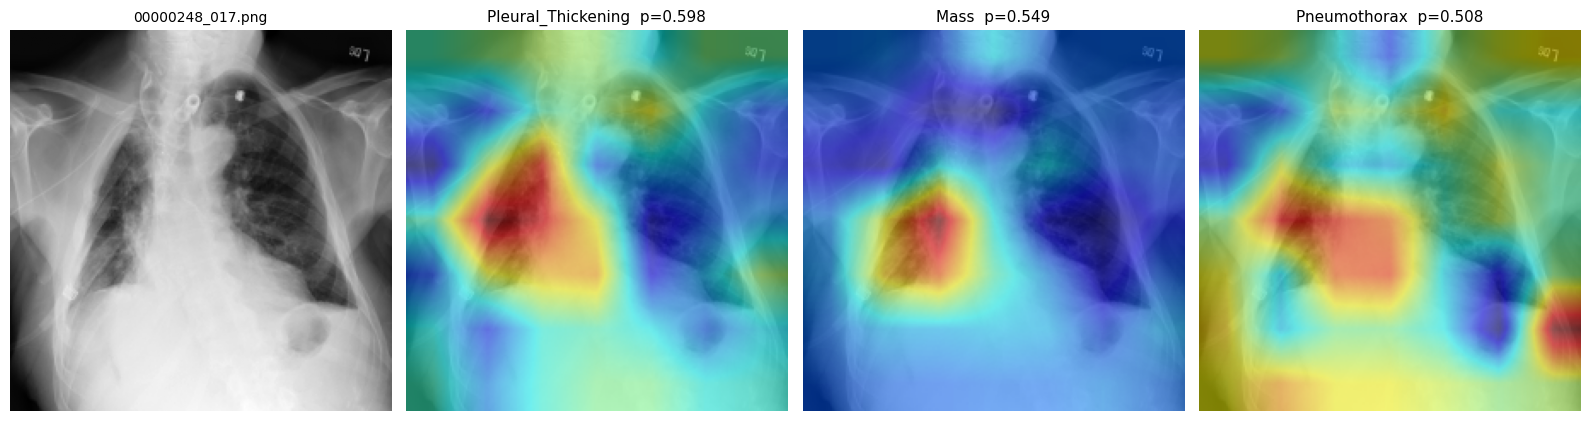

GT: Mass
  Pleural_Thickening   0.5979
  Mass                 0.5493
  Pneumothorax         0.5078
  Consolidation        0.3195
  Fibrosis             0.3031
  Emphysema            0.2087
  Atelectasis          0.1900
  Effusion             0.1896
  Nodule               0.1569
  Infiltration         0.1307
  Pneumonia            0.1067
  Cardiomegaly         0.0539
  Edema                0.0053


In [36]:
# ── chạy thử ──
test_loc = 1020

row = all_xray_df.dropna(subset=["path"]).iloc[test_loc]  #? lấy row từ CHÍNH df đã dropna — iloc trên df gốc trỏ sang ảnh khác vì dropna đánh lại vị trí

print(row[["Finding Labels", "disease_vec"]])  #? row là Series → index bằng list nhãn, không có kwarg columns=

probs = show_cam(row["path"], topk=3)

print("GT:", row["Finding Labels"])
for name, p in sorted(zip(CFG["label_cols"], probs), key=lambda t: -t[1]):
    print(f"  {name:20s} {p:.4f}")

In [37]:
import os
import time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# ==========================================
# CPU benchmark setup
# ==========================================

CPU_THREADS = min(4, os.cpu_count() or 1)
torch.set_num_threads(CPU_THREADS)


cpu_device = torch.device("cpu")
model = model.to(cpu_device)
model.eval()

mean = torch.tensor(
    IMAGENET_MEAN,
    dtype=torch.float32,
    device=cpu_device
).view(1, 3, 1, 1)

std = torch.tensor(
    IMAGENET_STD,
    dtype=torch.float32,
    device=cpu_device
).view(1, 3, 1, 1)


def to_device_float(x):
    x = x.to(cpu_device).float().div_(255.0)
    x = x.expand(-1, 3, -1, -1)
    return (x - mean) / std

print("PyTorch:", torch.__version__)
print("CPU threads:", torch.get_num_threads())
print("Model device:", next(model.parameters()).device)

n_params = sum(p.numel() for p in model.parameters())

print(f"Parameters: {n_params / 1e6:.2f} M")

PyTorch: 2.10.0+cu128
CPU threads: 4
Model device: cpu
Parameters: 8.02 M


In [38]:
def benchmark_cpu_pipeline(
    model,
    dataset,
    batch_sizes=(1, 4, 8, 16),
    warmup_batches=10,
    benchmark_batches=100,
):
    results = []

    model.eval()

    for batch_size in batch_sizes:

        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,      # quan trọng: đo data loading rõ ràng
            pin_memory=False,
        )

        # =========================================================
        # 1. WARMUP
        # Không tính vào benchmark
        # =========================================================
        iterator = iter(loader)

        with torch.inference_mode():
            for _ in range(warmup_batches):
                try:
                    batch = next(iterator)
                except StopIteration:
                    break

                x = to_device_float(batch["pixel_values"])
                _ = model(x)

        # =========================================================
        # 2. ACTUAL BENCHMARK
        # Tạo iterator mới để benchmark lại từ đầu
        # =========================================================
        iterator = iter(loader)

        load_times = []
        preprocess_times = []
        forward_times = []
        total_times = []

        n_images = 0

        with torch.inference_mode():

            for _ in range(benchmark_batches):

                # -----------------------------------------------
                # START toàn bộ pipeline của 1 batch
                # -----------------------------------------------
                t0 = time.perf_counter()

                # -----------------------------------------------
                # A. DATA LOADING
                # -----------------------------------------------
                try:
                    batch = next(iterator)
                except StopIteration:
                    break

                t1 = time.perf_counter()

                # -----------------------------------------------
                # B. PREPROCESSING
                # -----------------------------------------------
                x = to_device_float(batch["pixel_values"])

                t2 = time.perf_counter()

                # -----------------------------------------------
                # C. MODEL FORWARD
                # -----------------------------------------------
                _ = model(x)

                t3 = time.perf_counter()

                # -----------------------------------------------
                # Save timing
                # -----------------------------------------------
                load_times.append(t1 - t0)
                preprocess_times.append(t2 - t1)
                forward_times.append(t3 - t2)
                total_times.append(t3 - t0)

                n_images += x.shape[0]

        load_times = np.array(load_times)
        preprocess_times = np.array(preprocess_times)
        forward_times = np.array(forward_times)
        total_times = np.array(total_times)

        # =========================================================
        # Convert về ms / image
        # =========================================================

        load_ms_per_image = load_times.sum() / n_images * 1000

        preprocess_ms_per_image = (
            preprocess_times.sum() / n_images * 1000
        )

        forward_ms_per_image = (
            forward_times.sum() / n_images * 1000
        )

        end_to_end_ms_per_image = (
            total_times.sum() / n_images * 1000
        )

        # throughput
        model_images_per_sec = (
            n_images / forward_times.sum()
        )

        end_to_end_images_per_sec = (
            n_images / total_times.sum()
        )

        # batch latency statistics
        median_forward_batch_ms = (
            np.median(forward_times) * 1000
        )

        p95_forward_batch_ms = (
            np.percentile(forward_times, 95) * 1000
        )

        median_e2e_batch_ms = (
            np.median(total_times) * 1000
        )

        p95_e2e_batch_ms = (
            np.percentile(total_times, 95) * 1000
        )

        results.append({
            "batch_size": batch_size,
            "n_images": n_images,

            "load_ms/img": load_ms_per_image,
            "preprocess_ms/img": preprocess_ms_per_image,

            "forward_ms/img": forward_ms_per_image,
            "e2e_ms/img": end_to_end_ms_per_image,

            "model_img/s": model_images_per_sec,
            "e2e_img/s": end_to_end_images_per_sec,

            "median_forward_batch_ms": median_forward_batch_ms,
            "p95_forward_batch_ms": p95_forward_batch_ms,

            "median_e2e_batch_ms": median_e2e_batch_ms,
            "p95_e2e_batch_ms": p95_e2e_batch_ms,
        })

    return pd.DataFrame(results)

In [39]:
benchmark_df = benchmark_cpu_pipeline(
    model=model,
    dataset=test_ds,
    batch_sizes=[1, 4, 8, 16],
    warmup_batches=10,
    benchmark_batches=100,
)

display(benchmark_df.round(2))

,batch_size,n_images,load_ms/img,preprocess_ms/img,forward_ms/img,e2e_ms/img,model_img/s,e2e_img/s,median_forward_batch_ms,p95_forward_batch_ms,median_e2e_batch_ms,p95_e2e_batch_ms
0,1,100,0.38,0.16,288.28,288.82,3.47,3.46,284.69,319.80,285.21,320.39
1,4,400,0.15,0.12,250.23,250.51,4.00,3.99,994.29,1046.85,995.80,1047.93
2,8,800,0.10,0.10,254.96,255.16,3.92,3.92,2028.12,2117.89,2029.71,2119.47
3,16,1600,0.07,0.10,258.27,258.43,3.87,3.87,4136.71,4259.96,4139.49,4262.60


In [40]:
cuda_device = torch.device("cuda")

model = model.to(cuda_device)
model.eval()

cuda_mean = torch.tensor(
    IMAGENET_MEAN,
    dtype=torch.float32,
    device=cuda_device
).view(1, 3, 1, 1)

cuda_std = torch.tensor(
    IMAGENET_STD,
    dtype=torch.float32,
    device=cuda_device
).view(1, 3, 1, 1)


def to_cuda_float(x):
    x = x.to(cuda_device, non_blocking=True).float().div_(255.0)
    x = x.expand(-1, 3, -1, -1)

    return (x - cuda_mean) / cuda_std

In [41]:
@torch.inference_mode()
def evaluate_cuda(model, dataset, batch_size=64):

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    model.eval()

    all_logits = []
    all_labels = []

    total_loss = 0.0
    n_seen = 0

    for batch in tqdm(loader, desc="CUDA evaluation"):

        x = to_cuda_float(batch["pixel_values"])

        labels = batch["labels"].to(
            cuda_device,
            non_blocking=True
        )

        # --------------------------
        # GPU inference
        # --------------------------
        logits = model(x)

        loss = criterion(logits, labels)

        bs = x.size(0)

        total_loss += loss.item() * bs
        n_seen += bs

        # chuyển kết quả về CPU để tính AUC
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

    # CPU
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)

    probs = logits.sigmoid().numpy()
    y_true = labels.numpy()

    # sklearn / numpy -> CPU
    mean_auc, per_class_auc = auc_per_class(
        y_true,
        probs,
        verbose=True,
    )

    avg_loss = total_loss / n_seen

    return avg_loss, mean_auc, per_class_auc

In [42]:
test_loss, test_auc, test_auc_per_class = evaluate_cuda(
    model,
    test_ds,
    batch_size=64,
)

print("\n============================")
print("TEST RESULT")
print("============================")
print(f"Loss     : {test_loss:.4f}")
print(f"Mean AUC : {test_auc:.4f}")

CUDA evaluation: 100%|██████████| 400/400 [01:22<00:00,  4.82it/s]

  Infiltration         0.6748
  Pneumonia            0.6905
  Consolidation        0.7174
  Nodule               0.7360
  Atelectasis          0.7422
  Pleural_Thickening   0.7490
  Mass                 0.7850
  Fibrosis             0.8025
  Effusion             0.8055
  Edema                0.8291
  Pneumothorax         0.8442
  Cardiomegaly         0.8611
  Emphysema            0.8835
  ── MEAN              0.7785

TEST RESULT
Loss     : 0.6229
Mean AUC : 0.7785
